# BurstCube Ancillary Data: Orbit, Attitude, GTI/SAA, HK, Timeline, Catalog

This notebook covers everything around the science data itself: spacecraft
position (`gdt.missions.burstcube.orbit`), attitude
(`gdt.missions.burstcube.attitude` and `gdt.missions.burstcube.frame`),
good-time-interval and SAA filtering (`gdt.missions.burstcube.gti`,
`gdt.missions.burstcube.saa`), detector housekeeping
(`gdt.missions.burstcube.hk`), the mission timeline
(`gdt.missions.burstcube.timeline`), and the observation catalog
(`gdt.missions.burstcube.catalog`). It uses the same day, 240530, as the
other two notebooks, plus the mission-long trend products (attitude, GTI,
timeline), which are not tied to any one day.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from gdt.missions.burstcube.finders import BurstCubeObsFinder, BurstCubeTrendFinder
from gdt.missions.burstcube.orbit import BurstCubeOrbit
from gdt.missions.burstcube.attitude import BurstCubeAttitude, APPROXIMATE_POINTING_ERROR_DEG
from gdt.missions.burstcube.frame import BurstCubeFrame
from gdt.missions.burstcube.gti import BurstCubeGti, intersect, union, complement, apply_to
from gdt.missions.burstcube.saa import BurstCubeSaa
from gdt.missions.burstcube.hk import BurstCubeDetectorHk
from gdt.missions.burstcube.timeline import BurstCubeTimeline
from gdt.missions.burstcube.catalog import BurstCubeObsCatalog
from gdt.missions.burstcube.cbd import BurstCubeCbd
from gdt.core.data_primitives import Gti

OBS_ID = '240530'
DETECTOR = 'CS0'
data_dir = Path('/tmp/claude-0/-home-user-gdt-burstcube/447d6658-321e-5b62-9705-df9af1930227/scratchpad/bcdata/nb3')
data_dir.mkdir(parents=True, exist_ok=True)
%matplotlib inline

## Orbit: spacecraft position and Earth position

The orbit file (`auxil/bcYYMMDD.hk.gz`) carries the reconstructed spacecraft
position/velocity, not attitude -- `INSTRUME='CS'` here, not a detector or
`'CSA'`. It converts directly to a `BurstCubeFrame` with
`obsgeoloc`/`obsgeovel` set and no quaternion, which is enough for
Earth-visibility/geocenter work but not for sky positions.

In [2]:
finder = BurstCubeObsFinder(OBS_ID)
orbit_path = finder.get_orbit(data_dir)
print(f'orbit file: {orbit_path}')

orbit = BurstCubeOrbit.open(orbit_path)
frame = orbit.get_spacecraft_frame()
print(f'{len(frame.obstime)} orbit rows, time range '
     f'{frame.obstime.min().burstcube:.1f} to {frame.obstime.max().burstcube:.1f} (MET)')

import astropy.units as u

loc = frame.obsgeoloc
r_km = np.sqrt(loc.x**2 + loc.y**2 + loc.z**2).to(u.km)
print(f'spacecraft geocentric distance: min={r_km.min().value:.1f} km, '
     f'max={r_km.max().value:.1f} km')
print(f'no quaternion on this frame: {frame.quaternion is None}')

Output()

orbit file: /tmp/claude-0/-home-user-gdt-burstcube/447d6658-321e-5b62-9705-df9af1930227/scratchpad/bcdata/nb3/bc240530.hk.gz
2899 orbit rows, time range 107568002.4 to 107654372.9 (MET)
spacecraft geocentric distance: min=6766.3 km, max=6776.1 km
no quaternion on this frame: True


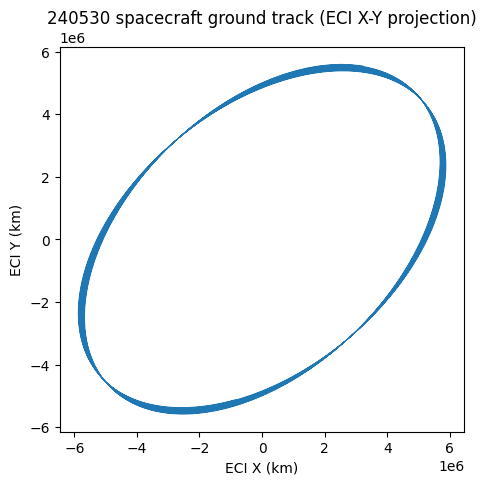

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(loc.x.value, loc.y.value, lw=0.5)
ax.set_xlabel('ECI X (km)')
ax.set_ylabel('ECI Y (km)')
ax.set_title(f'{OBS_ID} spacecraft ground track (ECI X-Y projection)')
ax.set_aspect('equal')
plt.show()

## Attitude: the 3 reconstructed epochs, and supplying your own quaternion

Per archive caveat #1, real reconstructed attitude exists for only 3 brief
epochs across the entire mission, with ~10-12 deg pointing errors even then
(`APPROXIMATE_POINTING_ERROR_DEG`). `trend/attitude/bc_csa_att.fits` exposes
exactly those 3 rows and deliberately does **not** interpolate between them
-- doing so would fabricate data the mission does not have.

In [4]:
trend_finder = BurstCubeTrendFinder()
att_path = trend_finder.get_attitude(data_dir)
print(f'attitude file: {att_path}')

att = BurstCubeAttitude.open(att_path)
print(f'{att.num_rows} attitude epochs in the whole archive')
for i in range(att.num_rows):
    ra, dec, roll = att.pointing[i]
    print(f'  epoch {i}: MET={att.time[i].burstcube:.3f}  boresight RA={ra:.4f} Dec={dec:.4f}  '
         f'roll={roll:.4f}  (~{APPROXIMATE_POINTING_ERROR_DEG[i]} deg 1-sigma)')

Output()

attitude file: /tmp/claude-0/-home-user-gdt-burstcube/447d6658-321e-5b62-9705-df9af1930227/scratchpad/bcdata/nb3/bc_csa_att.fits
3 attitude epochs in the whole archive
  epoch 0: MET=110220808.000  boresight RA=48.7231 Dec=10.8619  roll=333.9504  (~10.0 deg 1-sigma)
  epoch 1: MET=111198020.000  boresight RA=350.9859 Dec=49.4582  roll=297.4166  (~12.0 deg 1-sigma)
  epoch 2: MET=111465000.000  boresight RA=182.6820 Dec=-46.0375  roll=69.1484  (~10.5 deg 1-sigma)


In [5]:
# Use epoch 0's own frame to recover its own documented boresight pointing,
# as a check that the quaternion convention (scalar-last QPARAM) round-trips.
# The frame's own representation is (az, el) -- el, not zenith -- with the
# boresight at az=0, el=90.
from astropy.coordinates import SkyCoord

epoch = 0
epoch_frame = att.frame(epoch)
boresight = SkyCoord(az=0, el=90, unit='deg', frame=epoch_frame).icrs
ra_doc, dec_doc, roll_doc = att.pointing[epoch]
print(f'reconstructed boresight: RA={np.asarray(boresight.ra.deg).item():.6f}, '
     f'Dec={np.asarray(boresight.dec.deg).item():.6f}')
print(f'file POINTING column:    RA={ra_doc:.6f}, Dec={dec_doc:.6f}')

reconstructed boresight: RA=48.723068, Dec=10.861863
file POINTING column:    RA=48.723068, Dec=10.861862


For every other time -- essentially all of the mission, including this
notebook's worked day, 240530, which does not coincide with any of the 3
epochs -- there is no attitude file to open. The documented path is to
supply your own reconstructed quaternion via
`BurstCubeFrame.from_quaternion`. Here we reuse epoch 0's real quaternion as
a stand-in, retimed to a moment during 240530, purely to demonstrate the
mechanism -- this is **not** a claim that the spacecraft was actually at
that orientation on 240530.

In [6]:
from astropy.time import Time as AstropyTime

demo_quaternion = att.quaternion[epoch].scalar_last  # the 4 floats (x, y, z, w)
demo_time = AstropyTime('2024-05-30T12:00:00')
user_frame = BurstCubeFrame.from_quaternion(demo_quaternion, demo_time)

demo_coord = SkyCoord(ra=48.723068, dec=10.861862, unit='deg')
sc_coord = demo_coord.transform_to(user_frame)
az = np.asarray(sc_coord.az.deg).item()
zen = 90.0 - np.asarray(sc_coord.el.deg).item()
print(f'RA/Dec -> spacecraft frame: az={az:.4f}, zen={zen:.4f}')
print('zen=0 as expected: this is the same quaternion whose own documented')
print('boresight is this exact RA/Dec, just retimed. (az itself is not')
print('physically meaningful here -- azimuth is degenerate exactly at')
print('zen=0, the same way RA is undefined exactly at a celestial pole;')
print('a fraction of a degree off boresight gives a well-defined az.)')

RA/Dec -> spacecraft frame: az=283.6370, zen=0.0000
zen=0 as expected: this is the same quaternion whose own documented
boresight is this exact RA/Dec, just retimed. (az itself is not
physically meaningful here -- azimuth is degenerate exactly at
zen=0, the same way RA is undefined exactly at a celestial pole;
a fraction of a degree off boresight gives a well-defined az.)


## GTI and SAA filtering

Three different kinds of "good time" apply to BurstCube data: the per-file
`STDGTI` extension bundled with CBD/TTE, the standalone mission-long trend
GTI files (valid-binning, positive-counts, SAA in/out), and the SAA
boundary polygon itself (a geographic region, not a time interval).

In [7]:
gti_path = trend_finder.get_gti_saa(data_dir, variant='in_cl')
print(f'SAA trend GTI file: {gti_path}')
saa_gti = BurstCubeGti.open(gti_path).gti
saa_intervals = saa_gti.as_list()
print(f'{len(saa_intervals)} SAA-passage intervals in the trend file')
print(f'first 3: {saa_intervals[:3]}')

Output()

SAA trend GTI file: /tmp/claude-0/-home-user-gdt-burstcube/447d6658-321e-5b62-9705-df9af1930227/scratchpad/bcdata/nb3/bc_csa_saa_in_cl.gti
586 SAA-passage intervals in the trend file
first 3: [(107629482.71931195, 107630000.214), (107630001.238, 107630322.71931219), (107632062.71931195, 107632546.86)]


In [8]:
cl_path = finder.get_cbd(data_dir, detectors=DETECTOR, variant='cl')[0]
uf_path = finder.get_cbd(data_dir, detectors=DETECTOR, variant='uf')[0]
cbd_cl = BurstCubeCbd.open(cl_path)
cbd_uf = BurstCubeCbd.open(uf_path)
print(f'_uf bins: {cbd_uf.data.size[0]}, own STDGTI: {len(cbd_uf.gti.as_list())} intervals')
print(f'_cl bins: {cbd_cl.data.size[0]}, own STDGTI: {len(cbd_cl.gti.as_list())} intervals')

gap_gti = complement(cbd_uf.gti, cbd_uf.data.tstart[0], cbd_uf.data.tstop[-1])
n_gaps = len(gap_gti.as_list()) if gap_gti is not None else 0
print(f'{n_gaps} gaps in the _uf GTI over its own time span -- the instrument was')
print('off or unstable this often even within a single observation day')

Output()

Output()

_uf bins: 98188, own STDGTI: 4 intervals
_cl bins: 12576, own STDGTI: 5 intervals
4 gaps in the _uf GTI over its own time span -- the instrument was
off or unstable this often even within a single observation day


In [9]:
# Try to reproduce _cl's own GTI-driven cut in one call, starting from _uf
# and its own bundled (multi-segment) GTI.
try:
    reconstructed_cl = apply_to(cbd_uf.gti, cbd_uf)
except TypeError as err:
    print(f'apply_to on the whole multi-segment GTI raised: {type(err).__name__}: {err}')

apply_to on the whole multi-segment GTI raised: TypeError: 'NoneType' object is not subscriptable


That is a real, practical limitation, not a bug in this plugin: `apply_to`
is a thin wrapper over gdt-core's own `Phaii.slice_time`, and the installed
gdt-core's `slice_time` intersects the requested segments' own GTIs
*cumulatively* rather than taking their union, so passing more than one
disjoint time range at once collapses to an empty intersection. The
workaround is to apply each GTI segment separately (which works, since
each call passes exactly one range) and merge the results:

In [10]:
segments = cbd_uf.gti.as_list()
print(f'{len(segments)} disjoint segments in the _uf GTI')

parts = [apply_to(Gti.from_list([seg]), cbd_uf) for seg in segments]
print(f'bins per segment: {[p.data.size[0] for p in parts]}')

reconstructed_cl = parts[0]
for part in parts[1:]:
    reconstructed_cl = reconstructed_cl.merge([reconstructed_cl, part])

print(f'_uf sliced segment-by-segment and merged: {reconstructed_cl.data.size[0]} bins')
print(f'archive _cl file directly:                {cbd_cl.data.size[0]} bins')

4 disjoint segments in the _uf GTI
bins per segment: [2879, 9944, 55913, 29448]
_uf sliced segment-by-segment and merged: 98184 bins
archive _cl file directly:                12576 bins


The SAA boundary itself is a static polygon in geographic
longitude/latitude, from CALDB, not a time interval -- it needs the
spacecraft's ground position (from the orbit file above) to turn into a
yes/no per time.

In [11]:
saa = BurstCubeSaa()
print(f'SAA polygon: {len(saa.longitude)} vertices')

# BurstCubeOrbit gives ECI (GCRS) position; the SAA polygon is in geographic
# (Earth-fixed) longitude/latitude, so convert via ITRS -- a generic
# astropy operation, not BurstCube-specific.
from astropy.coordinates import GCRS, ITRS

gcrs = GCRS(loc, obstime=frame.obstime)
itrs = gcrs.transform_to(ITRS(obstime=frame.obstime))
earth = itrs.earth_location
ground_lon = earth.lon.deg
ground_lat = earth.lat.deg
print(f'ground track: lon range {ground_lon.min():.1f} to {ground_lon.max():.1f} deg, '
     f'lat range {ground_lat.min():.1f} to {ground_lat.max():.1f} deg')

SAA polygon: 19 vertices


ground track: lon range -180.0 to 179.9 deg, lat range -51.8 to 51.8 deg


242 of 2899 orbit rows this day fall inside the SAA polygon


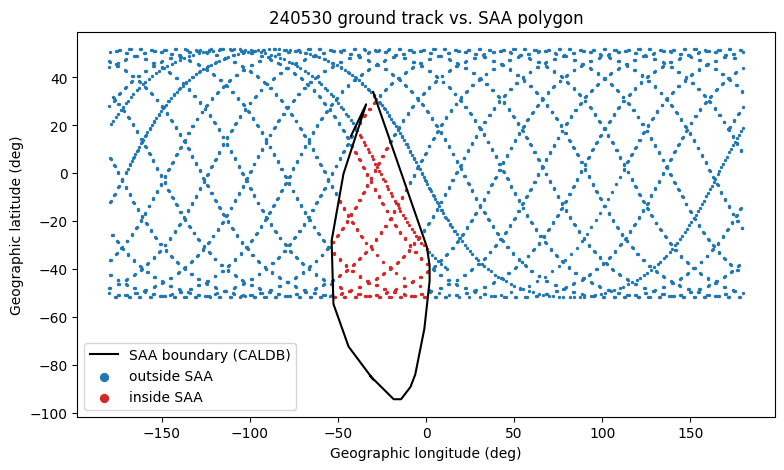

In [12]:
inside = saa.contains(ground_lon, ground_lat)
print(f'{inside.sum()} of {inside.size} orbit rows this day fall inside the SAA polygon')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(saa.longitude, saa.latitude, 'k-', lw=1.5, label='SAA boundary (CALDB)')
ax.scatter(ground_lon[~inside], ground_lat[~inside], s=2, c='tab:blue', label='outside SAA')
ax.scatter(ground_lon[inside], ground_lat[inside], s=2, c='tab:red', label='inside SAA')
ax.set_xlabel('Geographic longitude (deg)')
ax.set_ylabel('Geographic latitude (deg)')
ax.legend(markerscale=4)
ax.set_title(f'{OBS_ID} ground track vs. SAA polygon')
plt.show()

## Detector housekeeping: enable flags and energy thresholds

Per archive caveat #7, the per-detector energy thresholds were raised
mid-mission from ~21-30 keV to ~100 keV to suppress a non-Poissonian
low-energy noise component. `peak_threshold`/`base_threshold` (from
`DETECTOR_HK2`, 60 s cadence) carry that setting; the enable flags (from
`DETECTOR_HK1`, 1 s cadence) show whether a detector's trigger/data
collection was actually turned on. A single day only samples one side of a
mission-long change like this, so do not expect to see it move within one
day's data -- check across days (e.g. via the catalog, below) for that.

In [13]:
hk_path = finder.get_hk(data_dir)
hk = BurstCubeDetectorHk.open(hk_path)
print(f'HK1 (1 s cadence): {len(hk.hk1)} rows')
print(f'HK2 (60 s cadence): {len(hk.hk2)} rows')

for det in ('CS0', 'CS1', 'CS2', 'CS3'):
    peak = hk.peak_threshold(det)
    print(f'  {det}: PEAK_THRES range over the day: {peak.min():.2f}-{peak.max():.2f} mV, '
         f'DET_ENABLED fraction on: {hk.det_enabled(det).mean():.3f}')
print()
print('On 240530 specifically, PEAK_THRES is a flat constant for all 4')
print('detectors -- this day does not itself show the mid-mission change,')
print('it only shows one fixed setting.')

Output()

HK1 (1 s cadence): 2110 rows
HK2 (60 s cadence): 1053 rows
  CS0: PEAK_THRES range over the day: 6.00-6.00 mV, DET_ENABLED fraction on: 0.997
  CS1: PEAK_THRES range over the day: 6.00-6.00 mV, DET_ENABLED fraction on: 0.997
  CS2: PEAK_THRES range over the day: 6.00-6.00 mV, DET_ENABLED fraction on: 0.997
  CS3: PEAK_THRES range over the day: 6.00-6.00 mV, DET_ENABLED fraction on: 0.997

On 240530 specifically, PEAK_THRES is a flat constant for all 4
detectors -- this day does not itself show the mid-mission change,
it only shows one fixed setting.


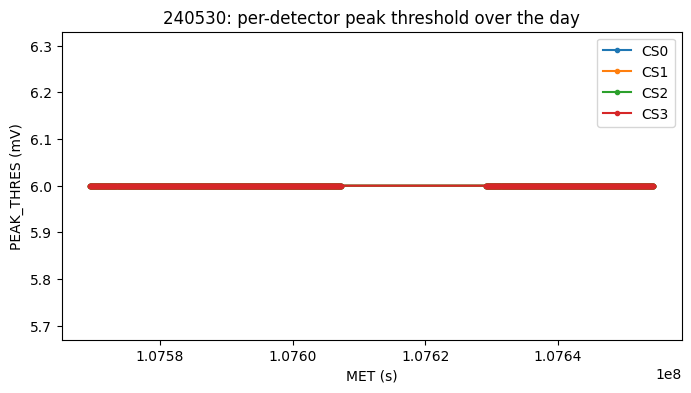

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
for det in ('CS0', 'CS1', 'CS2', 'CS3'):
    ax.plot(hk.hk2.time.burstcube, hk.peak_threshold(det), marker='o', ms=3, label=det)
ax.set_xlabel('MET (s)')
ax.set_ylabel('PEAK_THRES (mV)')
ax.legend()
ax.set_title(f'{OBS_ID}: per-detector peak threshold over the day')
plt.show()

## The mission timeline

`trend/*_timeline_final.csv` is a reconstructed log of spacecraft/instrument
events. Its MET column (converted here with the same
`gdt.missions.burstcube.time.BurstCubeSecTime` used everywhere else) is
authoritative; **its own UTC-string column is 37 s off from that same MET,
for every row it was checked against** -- do not use it.

In [15]:
timeline_path = trend_finder.get_timeline(data_dir)
print(f'timeline file: {timeline_path}')

timeline = BurstCubeTimeline.open(timeline_path)
print(f'{timeline.num_rows} timeline events across the mission')

row = 0
authoritative_utc = timeline.time[row].utc
written_utc = timeline.utc_as_written[row]
print(f'row {row}: MET={timeline.time[row].burstcube:.3f}')
print(f'  authoritative UTC (from MET):  {authoritative_utc}')
print(f'  CSV\'s own UTC-string column:  {written_utc}   <-- do not use this')

from astropy.time import Time as AstropyTime2
delta = (AstropyTime2(authoritative_utc) - AstropyTime2(written_utc)).sec
print(f'  difference: {delta:.3f} s')

Output()

timeline file: /tmp/claude-0/-home-user-gdt-burstcube/447d6658-321e-5b62-9705-df9af1930227/scratchpad/bcdata/nb3/20250606_timeline_final.csv
505 timeline events across the mission
row 0: MET=106367555.280
  authoritative UTC (from MET):  106367555.28030825
  CSV's own UTC-string column:  2024-05-16T02:31:58.280   <-- do not use this
  difference: 37.000 s


In [16]:
reboots = timeline.matching('Spacecraft Reboot')
print(f'{reboots.sum()} "Spacecraft Reboot" events in the timeline')

drift_rows = ~np.isnan(timeline.drift_seconds)
print(f'{drift_rows.sum()} "CBD Data Timestamp Drift (GPS Reboot)" events '
     f'with a parsed drift value')
if drift_rows.sum() > 0:
    print(f'drift magnitudes (s): {timeline.drift_seconds[drift_rows][:10]}')

68 "Spacecraft Reboot" events in the timeline
119 "CBD Data Timestamp Drift (GPS Reboot)" events with a parsed drift value
drift magnitudes (s): [-4.97 -0.26 -0.51 -0.51 -0.   -0.51  0.26 -0.26 -0.    0.26]


## The observation catalog (`burcbmastr`)

The HEASARC Browse catalog gives one row per observation day, with
per-detector exposure/rate/integration-time columns. Missing values (a
detector with no CBD that day) are NaN, never coerced to 0.

In [17]:
catalog = BurstCubeObsCatalog(cached=False, verbose=False)
print(f'{catalog.num_rows} rows in burcbmastr')

tte_cat = catalog.tte_days()
print(f'{tte_cat.num_rows} days with TTE data (num_events > 0)')
print(f'TTE obs IDs: {sorted(tte_cat._data["OBSID"].tolist())}')

84 rows in burcbmastr
7 days with TTE data (num_events > 0)
TTE obs IDs: ['240530', '240602', '240628', '240629', '240813', '240814', '240815']


In [18]:
exp = catalog.exposure(DETECTOR)
n_missing = np.isnan(exp).sum()
print(f'{DETECTOR} exposure: {n_missing} of {catalog.num_rows} days have no CBD (NaN), '
     f'not zero')
print(f'of the days with CBD, mean exposure = {np.nanmean(exp):.1f} s, '
     f'max = {np.nanmax(exp):.1f} s')

CS0 exposure: 39 of 84 days have no CBD (NaN), not zero
of the days with CBD, mean exposure = 20895.2 s, max = 85217.8 s


## Summary

* The orbit file gives spacecraft position/velocity only -- no attitude.
* Real attitude exists for 3 epochs total, each with ~10-12 deg pointing
  error; every other time needs a user-supplied quaternion via
  `BurstCubeFrame.from_quaternion`.
* `gti.apply_to` reproduces a `_cl` file's own cut starting from `_uf` and
  its bundled `STDGTI`; the SAA boundary is a separate, static geographic
  polygon that needs ground position, not time, to evaluate.
* Detector housekeeping shows the mid-mission energy threshold change and
  the enable-flag history directly.
* The timeline's MET column is authoritative; its own UTC-string column is
  wrong by 37 s and is kept only for reference.
* The catalog's per-detector columns are NaN, not 0, for days with no data
  for that detector.